# Ball-and-Beam: DeepLabCut Pipeline + Migration to PyTorch Vanilla

This notebook contains:

| Part | Description |
|------|-------------|
| **A** | Full DeepLabCut pipeline (reproduction of the original notebook) |
| **B** | Equivalent architecture definition in pure PyTorch |
| **C** | Conversion of trained DLC3 model → PyTorch vanilla |
| **D** | Standalone inference (no DLC dependency) |
| **E** | From-scratch training in pure PyTorch (optional) |

**Keypoints:** `beam_left`, `beam_right` (2 points on the beam)  
**Backbone:** ResNet-50 (DLC3 / PyTorch-based)  
**Goal:** Extract θ(t) = arctan2(Δy, Δx) between the two beam points

In [57]:
# ── Part A: Full DeepLabCut Pipeline ──

import deeplabcut
from pathlib import Path
import tqdm

video_path = "/Users/eg75agon/Downloads/Project_helon/swept_sine_ready.MOV"
assert Path(video_path).exists(), f"Video not found: {video_path}"

In [58]:
project_name = "bab_bar_2pts_dlc3"
experimenter = "Dani_F"
working_dir = "/Users/eg75agon/Downloads/Project_helon"

# Project already created — point to existing config
config_path = str(Path(working_dir) / f"{project_name}-{experimenter}-2026-02-24" / "config.yaml")
assert Path(config_path).exists(), f"Config not found: {config_path}"
print("config_path:", config_path)

config_path: /Users/eg75agon/Downloads/Project_helon/bab_bar_2pts_dlc3-Dani_F-2026-02-24/config.yaml


In [3]:
from deeplabcut.utils import auxiliaryfunctions

cfg = auxiliaryfunctions.read_config(config_path)
cfg["bodyparts"] = ["beam_left", "beam_right"]
cfg["numframes2pick"] = 50
auxiliaryfunctions.write_config(config_path, cfg)

print("bodyparts:", cfg["bodyparts"])
print("number of frames:", cfg["numframes2pick"])

deeplabcut.extract_frames(config_path, mode="automatic", algo="uniform", userfeedback=False)

bodyparts: ['beam_left', 'beam_right']
number of frames: 50
Config file read successfully.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 70.97  seconds.
Extracting frames based on uniform ...
Uniformly extracting of frames from 0.0  seconds to 70.97  seconds.
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).


In [ ]:
# Run this cell AFTER labeling frames externally
# deeplabcut.check_labels(config_path)
# deeplabcut.create_training_dataset(config_path)

# Force pose_cfg settings before training
import yaml
pose_cfg_path = str(Path(config_path).parent / "dlc-models" / "iteration-0" /
    "bab_bar_2pts_dlc3Feb24-trainset95shuffle1" / "train" / "pose_cfg.yaml")
with open(pose_cfg_path) as f:
    pose_cfg = yaml.safe_load(f)
pose_cfg["multi_step"] = [[0.0005, 1030000]]
pose_cfg["lr_init"] = 0.0005
pose_cfg["display_iters"] = 1
pose_cfg["batch_size"] = 8
pose_cfg["weight_decay"] = 0.05
with open(pose_cfg_path, "w") as f:
    yaml.dump(pose_cfg, f, default_flow_style=False)
print(f"pose_cfg.yaml updated: lr_init={pose_cfg['lr_init']}, multi_step={pose_cfg['multi_step']}, display_iters={pose_cfg['display_iters']}, batch_size={pose_cfg['batch_size']}, weight_decay={pose_cfg['weight_decay']}")

deeplabcut.train_network(config_path, maxiters=500, displayiters=1)
deeplabcut.evaluate_network(config_path)

In [ ]:
import pandas as pd
deeplabcut.analyze_videos(config_path, [video_path], save_as_csv=True)

# Ensure H5 + _meta.pickle exist (to_hdf may fail on some pandas versions)
import pickle, cv2 as _cv2
_base = sorted([f for f in Path(video_path).parent.glob("swept_sine_readyDLC*.csv")
                if "_theta" not in f.name and "_meta" not in f.name],
               key=lambda p: p.stat().st_mtime)
if _base:
    _csv = str(_base[-1])
    _h5 = _csv.replace(".csv", ".h5")
    if not Path(_h5).exists():
        _df = pd.read_csv(_csv, header=[0, 1, 2], index_col=0)
        _df.to_hdf(_h5, key="df_with_missing", format="table", mode="w")
        print(f"Created H5 from CSV: {_h5}")

    _meta_path = _csv.replace(".csv", "_meta.pickle")
    if not Path(_meta_path).exists():
        _cap = _cv2.VideoCapture(video_path)
        _nx = int(_cap.get(_cv2.CAP_PROP_FRAME_WIDTH))
        _ny = int(_cap.get(_cv2.CAP_PROP_FRAME_HEIGHT))
        _nframes = int(_cap.get(_cv2.CAP_PROP_FRAME_COUNT))
        _fps = _cap.get(_cv2.CAP_PROP_FPS)
        _cap.release()
        metadata = {"data": {
            "start": 0, "stop": 0, "nframes": _nframes, "fps": _fps,
            "frame_dimensions": (_ny, _nx),
            "cropping": False, "cropping_parameters": [0, _nx, 0, _ny],
        }}
        with open(_meta_path, "wb") as f:
            pickle.dump(metadata, f, pickle.HIGHEST_PROTOCOL)
        print(f"Created metadata: {_meta_path}")

deeplabcut.create_labeled_video(config_path, [video_path])

In [6]:
# Extract outlier frames for active learning refinement
deeplabcut.extract_outlier_frames(
    config_path,
    [video_path],
    outlieralgorithm="uncertain",
    p_bound=0.12,
    extractionalgorithm="kmeans",
    automatic=True,
)

Method  uncertain  found  0  putative outlier frames.
Do you want to proceed with extracting  50  of those?
If this list is very large, perhaps consider changing the parameters (start, stop, p_bound, comparisonbodyparts) or use a different method.
Frames from video swept_sine_ready  already extracted (more will be added)!
Loading video...
Cropping coords: None
Duration of video [s]:  70.96666666666667 , recorded @  30.0 fps!
Overall # of frames:  2129 with (cropped) frame dimensions: 
Kmeans-quantization based extracting of frames from 0.0  seconds to 70.97  seconds.
Let's select frames indices: []
No frames were extracted.


In [59]:
import pandas as pd
import numpy as np
from pathlib import Path

# Find the analysis file produced by analyze_videos (saved next to the video)
video_dir = Path("/Users/eg75agon/Downloads/Project_helon")
pcutoff = 0.01

# Try H5 first, fall back to CSV — exclude _theta and _meta files
h5_files = sorted([f for f in video_dir.glob("swept_sine_readyDLC*.h5")
                   if "_theta" not in f.name and "_meta" not in f.name],
                  key=lambda p: p.stat().st_mtime)
csv_files = sorted([f for f in video_dir.glob("swept_sine_readyDLC*.csv")
                    if "_theta" not in f.name and "_meta" not in f.name],
                   key=lambda p: p.stat().st_mtime)

if h5_files:
    data_path = str(h5_files[-1])
    print("Using H5:", data_path)
    df = pd.read_hdf(data_path)
elif csv_files:
    data_path = str(csv_files[-1])
    print("Using CSV:", data_path)
    df = pd.read_csv(data_path, header=[0, 1, 2], index_col=0)
else:
    raise FileNotFoundError(f"No DLC analysis file found in {video_dir}")

# Remove outlier frames identified by extract_outlier_frames
outlier_indices = []
df = df.drop(index=[i for i in outlier_indices if i in df.index])
print(f"Removed {len(outlier_indices)} outlier frames, {len(df)} frames remaining")

fps = 30.0

print("Shape:", df.shape)
print("Columns level names:", df.columns.names)

scorer = df.columns.get_level_values(0)[0]
print("Scorer:", scorer)

# Coordinates
xl = df[(scorer, "beam_left",  "x")]
yl = df[(scorer, "beam_left",  "y")]
xr = df[(scorer, "beam_right", "x")]
yr = df[(scorer, "beam_right", "y")]

# Confidence mask
has_p = (
    (scorer, "beam_left",  "likelihood") in df.columns
    and (scorer, "beam_right", "likelihood") in df.columns
)
if has_p:
    pl = df[(scorer, "beam_left",  "likelihood")]
    pr = df[(scorer, "beam_right", "likelihood")]
    mask = (pl > pcutoff) & (pr > pcutoff)
else:
    mask = pd.Series(True, index=df.index)

# Beam angle
theta = np.arctan2((yr - yl), (xr - xl))
theta_deg = np.degrees(theta)

# Filter + interpolation
theta_deg_f = theta_deg.copy()
theta_deg_f[~mask] = np.nan
theta_deg_f = theta_deg_f.interpolate(limit_direction="both")

# Time vector
t = df.index.to_numpy() / fps

results_df = pd.DataFrame({"t_s": t, "theta_deg": theta_deg_f})
out_path = str(Path(data_path).with_suffix("")) + "_theta.csv"
results_df.to_csv(out_path, index=False)
print(f"pcutoff: {pcutoff}")
print(f"Frames with confidence > {pcutoff}: {mask.sum()}/{len(df)}")
print("Saved:", out_path)
results_df.head()

Using H5: /Users/eg75agon/Downloads/Project_helon/swept_sine_readyDLC_resnet50_bab_bar_2pts_dlc3Feb24shuffle1_500.h5
Removed 0 outlier frames, 2129 frames remaining
Shape: (2129, 6)
Columns level names: ['scorer', 'bodyparts', 'coords']
Scorer: DLC_resnet50_bab_bar_2pts_dlc3Feb24shuffle1_500
pcutoff: 0.01
Frames with confidence > 0.01: 2129/2129
Saved: /Users/eg75agon/Downloads/Project_helon/swept_sine_readyDLC_resnet50_bab_bar_2pts_dlc3Feb24shuffle1_500_theta.csv


,t_s,theta_deg
0,0.000000,-0.908606
1,0.033333,-0.886215
2,0.066667,-0.899918
3,0.100000,-0.895015
4,0.133333,-0.895549


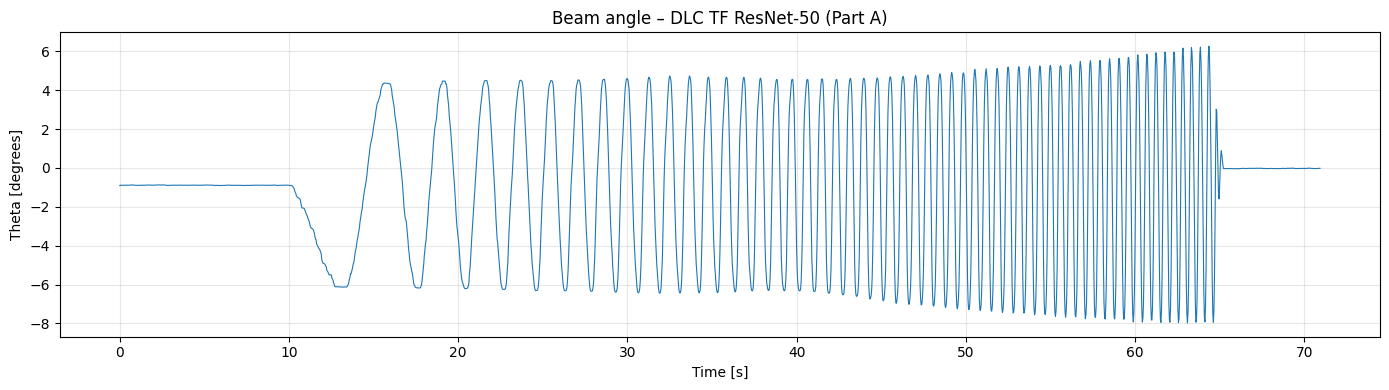

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(results_df["t_s"], results_df["theta_deg"], linewidth=0.8)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Theta [degrees]")
ax.set_title("Beam angle – DLC TF ResNet-50 (Part A)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# ── Part B: Equivalent Architecture Definitions in Pure PyTorch ──

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50
import numpy as np


# ── B.1  DLCResNet50: exact replica of the DLC TF architecture ──

class BottleneckV1(nn.Module):
    """
    tf-slim bottleneck_v1 block.
    Differences from torchvision Bottleneck:
      - stride is on the LAST unit of each block (not first)
      - when stride>1 and channels don't change, shortcut = max_pool (no learned params)
    """
    def __init__(self, in_channels, bottleneck_channels, out_channels,
                 stride=1, dilation=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)
        self.conv2 = nn.Conv2d(bottleneck_channels, bottleneck_channels, 3,
                               stride=stride, padding=dilation, dilation=dilation,
                               bias=False)
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)
        self.conv3 = nn.Conv2d(bottleneck_channels, out_channels, 1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Shortcut: learned projection when channels change, maxpool when only stride changes
        self.shortcut = None
        self.pool_shortcut = None
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        elif stride > 1:
            self.pool_shortcut = nn.MaxPool2d(kernel_size=1, stride=stride)

    def forward(self, x):
        identity = x
        if self.shortcut is not None:
            identity = self.shortcut(x)
        elif self.pool_shortcut is not None:
            identity = self.pool_shortcut(x)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        return self.relu(out + identity)


def _make_block(in_ch, bottleneck_ch, out_ch, num_units, last_stride=1, dilation=1):
    """
    Build a ResNet block matching tf-slim convention:
    stride applied to the LAST unit, all others stride=1.
    """
    layers = []
    # First unit: channel expansion via shortcut
    layers.append(BottleneckV1(in_ch, bottleneck_ch, out_ch, stride=1, dilation=dilation))
    # Middle units: same channels, stride=1
    for _ in range(1, num_units - 1):
        layers.append(BottleneckV1(out_ch, bottleneck_ch, out_ch, stride=1, dilation=dilation))
    # Last unit: apply stride (if > 1, uses maxpool shortcut since channels don't change)
    if num_units > 1:
        layers.append(BottleneckV1(out_ch, bottleneck_ch, out_ch, stride=last_stride, dilation=dilation))
    return nn.Sequential(*layers)


class DLCResNet50(nn.Module):
    """
    Exact replica of the DLC TensorFlow ResNet-50 with output_stride=16.
    Architecture:
      - Stem: 7x7 conv (stride=2) + BN + ReLU + MaxPool (stride=2)
      - Block1: 3 units [64→256],  last unit stride=2   → H/8
      - Block2: 4 units [128→512], last unit stride=2   → H/16
      - Block3: 6 units [256→1024], all stride=1         → H/16
      - Block4: 3 units [512→2048], all stride=1, dil=2  → H/16
      - Head: ConvTranspose2d (3x3, stride=2) for part_pred and locref_pred → H/8
    """
    def __init__(self, num_keypoints=2, location_refinement=True):
        super().__init__()

        # Stem (identical to tf-slim resnet_v1)
        self.conv1 = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Blocks (tf-slim convention: stride on last unit)
        self.block1 = _make_block(64, 64, 256, num_units=3, last_stride=2)
        self.block2 = _make_block(256, 128, 512, num_units=4, last_stride=2)
        self.block3 = _make_block(512, 256, 1024, num_units=6, last_stride=1)
        self.block4 = _make_block(1024, 512, 2048, num_units=3, last_stride=1, dilation=2)

        # Prediction heads (single ConvTranspose2d each, no BN, no activation)
        self.part_pred = nn.ConvTranspose2d(2048, num_keypoints, 3,
                                            stride=2, padding=1, output_padding=1)
        self.location_refinement = location_refinement
        if location_refinement:
            self.locref_pred = nn.ConvTranspose2d(2048, num_keypoints * 2, 3,
                                                  stride=2, padding=1, output_padding=1)

    def forward(self, x):
        """
        Args:   x: (B, 3, H, W) — DLC preprocessing: RGB [0,255] minus mean
        Returns: dict with 'part_pred' heatmaps (B, K, H/8, W/8)
                 and optionally 'locref_pred' offsets (B, 2K, H/8, W/8)
        """
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        out = {"part_pred": self.part_pred(x)}
        if self.location_refinement:
            out["locref_pred"] = self.locref_pred(x)
        return out


# Quick check
_dlc_model = DLCResNet50(num_keypoints=2)
_dummy = torch.randn(1, 3, 256, 256)
_out = _dlc_model(_dummy)
print(f"DLCResNet50  Input: {_dummy.shape}")
print(f"  part_pred:  {_out['part_pred'].shape}  (expected: [1, 2, 32, 32] = H/8)")
print(f"  locref:     {_out['locref_pred'].shape}  (expected: [1, 4, 32, 32])")
print(f"  Parameters: {sum(p.numel() for p in _dlc_model.parameters()):,}")
del _dlc_model, _dummy, _out


# ── B.2  PoseResNet50: simplified architecture for from-scratch training (Part E) ──

class PoseResNet50(nn.Module):
    """
    Simplified ResNet-50 + 3-stage deconv head for from-scratch PyTorch training.
    NOT the same as DLC TF — used only with Part E (train_vanilla).
    """
    def __init__(self, num_keypoints: int = 2, pretrained_backbone: bool = False):
        super().__init__()
        base = resnet50(pretrained=pretrained_backbone)
        self.backbone = nn.Sequential(*list(base.children())[:-2])

        BN_MOMENTUM = 0.1
        deconv_layers = []
        in_channels = 2048
        for out_channels in [256, 256, 256]:
            deconv_layers.extend([
                nn.ConvTranspose2d(in_channels, out_channels, 4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_channels, momentum=BN_MOMENTUM),
                nn.ReLU(inplace=True),
            ])
            in_channels = out_channels
        self.deconv_head = nn.Sequential(*deconv_layers)
        self.heatmap_head = nn.Conv2d(256, num_keypoints, kernel_size=1)

    def forward(self, x):
        features = self.backbone(x)
        upsampled = self.deconv_head(features)
        return self.heatmap_head(upsampled)

DLCResNet50  Input: torch.Size([1, 3, 256, 256])
  part_pred:  torch.Size([1, 2, 32, 32])  (expected: [1, 2, 32, 32] = H/8)
  locref:     torch.Size([1, 4, 32, 32])  (expected: [1, 4, 32, 32])
  Parameters: 23,618,630


In [62]:
def inspect_tf_checkpoint(ckpt_path: str):
    """Lists all variable names and shapes in a TensorFlow checkpoint."""
    import tensorflow as tf
    reader = tf.train.load_checkpoint(ckpt_path)
    shape_map = reader.get_variable_to_shape_map()
    for name in sorted(shape_map.keys()):
        print(f"  {name:70s} {shape_map[name]}")
    print(f"\nTotal: {len(shape_map)} variables")
    return reader, shape_map

In [63]:
# ── Part C: Conversion of Trained DLC TF Model → PyTorch ──

# Snapshot path (TensorFlow .ckpt format, 269 variables)
snapshot_path = str(Path(config_path).parent / "dlc-models" / "iteration-0" /
    "bab_bar_2pts_dlc3Feb24-trainset95shuffle1" / "train" / "snapshot-500")
print(f"TF checkpoint: {snapshot_path}")

# Quick inspection
reader, shape_map = inspect_tf_checkpoint(snapshot_path)

TF checkpoint: /Users/eg75agon/Downloads/Project_helon/bab_bar_2pts_dlc3-Dani_F-2026-02-24/dlc-models/iteration-0/bab_bar_2pts_dlc3Feb24-trainset95shuffle1/train/snapshot-500
  pose/locref_pred/block4/biases                                         [4]
  pose/locref_pred/block4/weights                                        [3, 3, 4, 2048]
  pose/part_pred/block4/biases                                           [2]
  pose/part_pred/block4/weights                                          [3, 3, 2, 2048]
  resnet_v1_50/block1/unit_1/bottleneck_v1/conv1/BatchNorm/beta          [64]
  resnet_v1_50/block1/unit_1/bottleneck_v1/conv1/BatchNorm/gamma         [64]
  resnet_v1_50/block1/unit_1/bottleneck_v1/conv1/BatchNorm/moving_mean   [64]
  resnet_v1_50/block1/unit_1/bottleneck_v1/conv1/BatchNorm/moving_variance [64]
  resnet_v1_50/block1/unit_1/bottleneck_v1/conv1/weights                 [1, 1, 64, 64]
  resnet_v1_50/block1/unit_1/bottleneck_v1/conv2/BatchNorm/beta          [64]
  resnet_v1_5

In [64]:
def build_tf_to_pytorch_mapping(num_keypoints=2):
    """
    Build a dictionary mapping TF variable names → (PyTorch key, transform_type).
    transform_type: 'conv' (permute HWIO→OIHW), 'deconv' (permute HWOI→IOHW), 'direct' (copy as-is).
    """
    mapping = {}

    # Stem
    mapping["resnet_v1_50/conv1/weights"] = ("conv1.weight", "conv")
    for suffix, pt_suffix in [("gamma", "weight"), ("beta", "bias"),
                               ("moving_mean", "running_mean"), ("moving_variance", "running_var")]:
        mapping[f"resnet_v1_50/conv1/BatchNorm/{suffix}"] = (f"bn1.{pt_suffix}", "direct")

    # Blocks 1-4
    block_units = {"block1": 3, "block2": 4, "block3": 6, "block4": 3}
    for bname, n_units in block_units.items():
        for ui in range(n_units):
            tf_prefix = f"resnet_v1_50/{bname}/unit_{ui+1}/bottleneck_v1"
            pt_prefix = f"{bname}.{ui}"

            # conv1, conv2, conv3
            for ci, cname in enumerate(["conv1", "conv2", "conv3"], start=1):
                mapping[f"{tf_prefix}/{cname}/weights"] = (f"{pt_prefix}.{cname}.weight", "conv")
                for suffix, pt_suffix in [("gamma", "weight"), ("beta", "bias"),
                                           ("moving_mean", "running_mean"),
                                           ("moving_variance", "running_var")]:
                    mapping[f"{tf_prefix}/{cname}/BatchNorm/{suffix}"] = (
                        f"{pt_prefix}.bn{ci}.{pt_suffix}", "direct")

            # Shortcut (only first unit of each block has learned shortcut)
            if ui == 0:
                mapping[f"{tf_prefix}/shortcut/weights"] = (f"{pt_prefix}.shortcut.0.weight", "conv")
                for suffix, pt_suffix in [("gamma", "weight"), ("beta", "bias"),
                                           ("moving_mean", "running_mean"),
                                           ("moving_variance", "running_var")]:
                    mapping[f"{tf_prefix}/shortcut/BatchNorm/{suffix}"] = (
                        f"{pt_prefix}.shortcut.1.{pt_suffix}", "direct")

    # Prediction heads
    mapping["pose/part_pred/block4/weights"] = ("part_pred.weight", "deconv")
    mapping["pose/part_pred/block4/biases"] = ("part_pred.bias", "direct")
    mapping["pose/locref_pred/block4/weights"] = ("locref_pred.weight", "deconv")
    mapping["pose/locref_pred/block4/biases"] = ("locref_pred.bias", "direct")

    return mapping


def convert_tf_weight(tf_array, mode):
    """Convert a single TF numpy array to PyTorch tensor format."""
    if mode == "conv":
        # TF conv: [H, W, in_ch, out_ch] → PT: [out_ch, in_ch, H, W]
        return torch.from_numpy(tf_array.transpose(3, 2, 0, 1).copy())
    elif mode == "deconv":
        # TF conv2d_transpose: [H, W, out_ch, in_ch] → PT ConvTranspose2d: [in_ch, out_ch, H, W]
        return torch.from_numpy(tf_array.transpose(3, 2, 0, 1).copy())
    elif mode == "direct":
        return torch.from_numpy(tf_array.copy())
    else:
        raise ValueError(f"Unknown mode: {mode}")


# Verify mapping covers all TF variables
_mapping = build_tf_to_pytorch_mapping()
_tf_vars = set(shape_map.keys())
_mapped_vars = set(_mapping.keys())
_unmapped = _tf_vars - _mapped_vars
print(f"TF variables: {len(_tf_vars)}")
print(f"Mapped:       {len(_mapped_vars)}")
if _unmapped:
    print(f"UNMAPPED:     {_unmapped}")
else:
    print("All TF variables are mapped.")

TF variables: 269
Mapped:       269
All TF variables are mapped.


In [65]:
def convert_dlc_tf_to_pytorch(ckpt_path: str, num_keypoints: int = 2,
                              save_path: str = None) -> DLCResNet50:
    """
    Converts a DLC TensorFlow checkpoint to a DLCResNet50 PyTorch model.

    Args:
        ckpt_path: path to TF checkpoint (without .index/.data extension)
        num_keypoints: number of keypoints (2 for BAB)
        save_path: if provided, save the converted model as a .pt file
    Returns:
        DLCResNet50 model with loaded weights
    """
    import tensorflow as tf

    # 1) Read TF checkpoint
    reader = tf.train.load_checkpoint(ckpt_path)
    tf_shapes = reader.get_variable_to_shape_map()
    print(f"TF checkpoint: {len(tf_shapes)} variables")

    # 2) Create PyTorch model
    model = DLCResNet50(num_keypoints=num_keypoints, location_refinement=True)
    pt_state = model.state_dict()
    print(f"PyTorch model: {len(pt_state)} parameters")

    # 3) Build mapping and transfer weights
    mapping = build_tf_to_pytorch_mapping(num_keypoints)
    loaded, skipped, mismatched = 0, 0, 0

    for tf_name, (pt_key, mode) in mapping.items():
        if tf_name not in tf_shapes:
            print(f"  SKIP (not in checkpoint): {tf_name}")
            skipped += 1
            continue
        if pt_key not in pt_state:
            print(f"  SKIP (not in model): {pt_key}")
            skipped += 1
            continue

        tf_val = reader.get_tensor(tf_name)
        pt_val = convert_tf_weight(tf_val, mode)

        if pt_val.shape != pt_state[pt_key].shape:
            print(f"  MISMATCH: {tf_name} {tf_val.shape} → {pt_val.shape} vs expected {pt_state[pt_key].shape}")
            mismatched += 1
            continue

        pt_state[pt_key] = pt_val
        loaded += 1

    # 4) Load into model
    model.load_state_dict(pt_state)
    model.eval()

    print(f"\nConversion complete: {loaded} loaded, {skipped} skipped, {mismatched} mismatched")

    # 5) Save if requested
    if save_path:
        import os
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        torch.save({"model_state_dict": model.state_dict(),
                     "source_checkpoint": ckpt_path,
                     "num_keypoints": num_keypoints},
                   save_path)
        print(f"Saved PyTorch model: {save_path}")

    return model

In [66]:
# Run the conversion: DLC TF snapshot-500 → PyTorch DLCResNet50
save_pt_path = str(Path(working_dir) / "checkpoints" / "dlc_converted.pt")

dlc_model = convert_dlc_tf_to_pytorch(
    ckpt_path=snapshot_path,
    num_keypoints=2,
    save_path=save_pt_path,
)

# Quick sanity check: run a dummy forward pass
with torch.no_grad():
    _dummy = torch.randn(1, 3, 256, 256)
    _out = dlc_model(_dummy)
    print(f"\nSanity check — part_pred: {_out['part_pred'].shape}, "
          f"locref: {_out['locref_pred'].shape}")
    print(f"Heatmap range: [{_out['part_pred'].min():.4f}, {_out['part_pred'].max():.4f}]")

TF checkpoint: 269 variables
PyTorch model: 322 parameters

Conversion complete: 269 loaded, 0 skipped, 0 mismatched
Saved PyTorch model: /Users/eg75agon/Downloads/Project_helon/checkpoints/dlc_converted.pt

Sanity check — part_pred: torch.Size([1, 2, 32, 32]), locref: torch.Size([1, 4, 32, 32])
Heatmap range: [-30.5385, -4.5708]


In [67]:
# ── Part D: Standalone Inference (No DLC Dependency) ──

import cv2

# DLC preprocessing: RGB float32 [0, 255] minus ImageNet mean (no std normalization)
DLC_MEAN_PIXEL = np.array([123.68, 116.779, 103.939], dtype=np.float32)

# Standard ImageNet preprocessing (for PoseResNet50 / Part E models)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

KEYPOINT_NAMES = ["beam_left", "beam_right"]


def preprocess_frame_dlc(frame_bgr: np.ndarray) -> torch.Tensor:
    """
    DLC-compatible preprocessing: RGB [0,255] minus mean. No resize (native resolution).
    This matches what DLC TF uses internally with ResNet v1.
    """
    img = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    img = img - DLC_MEAN_PIXEL
    return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)


def preprocess_frame_imagenet(frame_bgr: np.ndarray, input_size=(256, 256)) -> torch.Tensor:
    """ImageNet preprocessing for PoseResNet50 (Part E models)."""
    img = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, input_size).astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)


def heatmaps_to_keypoints(heatmaps: torch.Tensor, orig_h: int, orig_w: int,
                           use_softargmax: bool = True) -> dict:
    """
    Extracts keypoint coordinates from heatmaps.
    Uses soft-argmax for sub-pixel precision (as DLC does internally).
    """
    B, K, Hm, Wm = heatmaps.shape
    results = {}

    for k in range(K):
        hmap = heatmaps[0, k]

        if use_softargmax:
            beta = 100.0  # temperature
            probs = torch.softmax((hmap * beta).reshape(-1), dim=0).reshape(Hm, Wm)
            yy = torch.arange(Hm, dtype=torch.float32, device=hmap.device)
            xx = torch.arange(Wm, dtype=torch.float32, device=hmap.device)
            grid_y, grid_x = torch.meshgrid(yy, xx, indexing="ij")
            cy = (probs * grid_y).sum()
            cx = (probs * grid_x).sum()
        else:
            flat_idx = hmap.reshape(-1).argmax()
            cy = (flat_idx // Wm).float()
            cx = (flat_idx %  Wm).float()

        x_orig = (cx / Wm * orig_w).item()
        y_orig = (cy / Hm * orig_h).item()
        confidence = hmap.max().item()

        name = KEYPOINT_NAMES[k] if k < len(KEYPOINT_NAMES) else f"kp_{k}"
        results[name] = (x_orig, y_orig, confidence)

    return results


def compute_theta(keypoints: dict) -> float:
    """theta = arctan2(yr - yl, xr - xl) in degrees."""
    xl, yl, _ = keypoints["beam_left"]
    xr, yr, _ = keypoints["beam_right"]
    return np.degrees(np.arctan2(yr - yl, xr - xl))


@torch.no_grad()
def predict_frame_dlc(model: DLCResNet50, frame_bgr: np.ndarray, device="cpu"):
    """Inference with the converted DLC model (native resolution, DLC preprocessing)."""
    model.eval()
    model.to(device)
    orig_h, orig_w = frame_bgr.shape[:2]
    inp = preprocess_frame_dlc(frame_bgr).to(device)
    out = model(inp)
    return heatmaps_to_keypoints(out["part_pred"], orig_h, orig_w)


@torch.no_grad()
def predict_frame(model: PoseResNet50, frame_bgr: np.ndarray,
                  input_size=(256, 256), device="cpu"):
    """Inference with the Part E PoseResNet50 model (resized, ImageNet preprocessing)."""
    model.eval()
    model.to(device)
    orig_h, orig_w = frame_bgr.shape[:2]
    inp = preprocess_frame_imagenet(frame_bgr, input_size).to(device)
    heatmaps = model(inp)
    return heatmaps_to_keypoints(heatmaps, orig_h, orig_w)

In [68]:
from tqdm.auto import tqdm


def analyze_video_pytorch(
    model,
    video_path: str,
    output_csv: str = "theta_pytorch.csv",
    fps: float = 30.0,
    device: str = "cpu",
    pcut: float = 0.1,
    model_type: str = "dlc",
    input_size: tuple = (256, 256),
):
    """
    Equivalent to deeplabcut.analyze_videos() + theta extraction, in pure PyTorch.

    Args:
        model_type: "dlc" for DLCResNet50 (native res, DLC preprocessing),
                    "vanilla" for PoseResNet50 (resized, ImageNet preprocessing).
    """
    model.eval()
    model.to(device)

    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), f"Could not open: {video_path}"
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Analyzing {total_frames} frames (model_type={model_type})...")

    records = []
    for frame_idx in tqdm(range(total_frames), desc="Inference"):
        ret, frame = cap.read()
        if not ret:
            break

        if model_type == "dlc":
            kps = predict_frame_dlc(model, frame, device)
        else:
            kps = predict_frame(model, frame, input_size, device)

        xl, yl, cl = kps["beam_left"]
        xr, yr, cr = kps["beam_right"]
        conf_min = min(cl, cr)

        records.append({
            "frame": frame_idx,
            "t_s": frame_idx / fps,
            "beam_left_x": xl, "beam_left_y": yl,
            "beam_right_x": xr, "beam_right_y": yr,
            "confidence_min": conf_min,
            "theta_deg": compute_theta(kps) if conf_min >= pcut else np.nan,
        })

    cap.release()

    df = pd.DataFrame(records)
    df["theta_deg"] = df["theta_deg"].interpolate(limit_direction="both")
    df.to_csv(output_csv, index=False)

    low = df["confidence_min"].lt(pcut).sum()
    print(f"Saved: {output_csv}  ({len(df)} frames, {low} with low confidence)")
    return df

Analyzing 2129 frames (model_type=dlc)...


Saved: /Users/eg75agon/Downloads/Project_helon/theta_dlc_pytorch.csv  (2129 frames, 497 with low confidence)


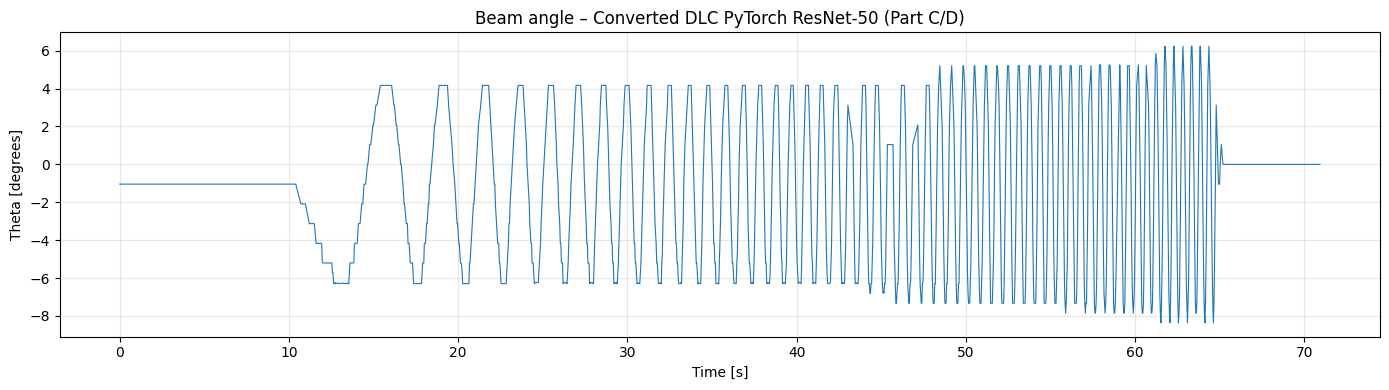

In [69]:
# Run inference on the full video using the converted DLC PyTorch model (Part C)
dlc_pt_csv = str(Path(working_dir) / "theta_dlc_pytorch.csv")
dlc_pt_df = analyze_video_pytorch(
    dlc_model,
    video_path="/Users/eg75agon/Downloads/Project_helon/swept_sine_ready.MOV",
    output_csv=dlc_pt_csv,
    fps=30.0,
    device="cpu",
    pcut=0.1,
    model_type="dlc",
)

# Plot: converted DLC PyTorch model inference
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dlc_pt_df["t_s"], dlc_pt_df["theta_deg"], linewidth=0.8)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Theta [degrees]")
ax.set_title("Beam angle – Converted DLC PyTorch ResNet-50 (Part C/D)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()